In [1]:
import json 
import numpy as np
import pandas as pd
import re, nltk, spacy, string
import en_core_web_sm
nlp = en_core_web_sm.load()
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from plotly.offline import plot
import plotly.graph_objects as go
import plotly.express as px

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, TfidfTransformer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
# from sklearn.metrics import plot_roc_curve
from pprint import pprint


In [2]:
# Import Textblob for extracting noun phrases
!pip install textblob
from textblob import TextBlob

In [6]:
# Installing wordcloud
!pip install wordcloud

from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

In [7]:
# Import pickle to save and load the model
import pickle

In [8]:
import nltk
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [10]:
df = pd.read_excel("C:\\Users\\DELL\\Downloads\\customer_support_tickets.xlsx")

In [11]:
df

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaT,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaT,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8464,8465,David Todd,adam28@example.net,22,Female,LG OLED,2021-12-08,Product inquiry,Installation support,My {product_purchased} is making strange noise...,Open,NaN,Low,Phone,NaT,NaT,NaN
8465,8466,Lori Davis,russell68@example.com,27,Female,Bose SoundLink Speaker,2020-02-22,Technical issue,Refund request,I'm having an issue with the {product_purchase...,Open,NaN,Critical,Email,NaT,NaT,NaN
8466,8467,Michelle Kelley,ashley83@example.org,57,Female,GoPro Action Camera,2021-08-17,Technical issue,Account access,I'm having an issue with the {product_purchase...,Closed,Eight account century nature kitchen.,High,Social media,2023-06-01 09:44:22,2023-06-01 04:31:22,3.0
8467,8468,Steven Rodriguez,fpowell@example.org,54,Male,PlayStation,2021-10-16,Product inquiry,Payment issue,I'm having an issue with the {product_purchase...,Closed,We seat culture plan.,Medium,Email,2023-06-01 18:28:24,2023-06-01 05:32:24,3.0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Ticket ID                     8469 non-null   int64         
 1   Customer Name                 8469 non-null   object        
 2   Customer Email                8469 non-null   object        
 3   Customer Age                  8469 non-null   int64         
 4   Customer Gender               8469 non-null   object        
 5   Product Purchased             8469 non-null   object        
 6   Date of Purchase              8469 non-null   datetime64[ns]
 7   Ticket Type                   8469 non-null   object        
 8   Ticket Subject                8469 non-null   object        
 9   Ticket Description            8469 non-null   object        
 10  Ticket Status                 8469 non-null   object        
 11  Resolution                    

In [18]:
df.describe()

,Ticket ID,Customer Age,Customer Satisfaction Rating
count,8469.000000,8469.000000,2769.000000
mean,4235.000000,44.026804,2.991333
std,2444.934048,15.296112,1.407016
min,1.000000,18.000000,1.000000
25%,2118.000000,31.000000,2.000000
50%,4235.000000,44.000000,3.000000
75%,6352.000000,57.000000,4.000000
max,8469.000000,70.000000,5.000000


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Ticket ID                     8469 non-null   int64         
 1   Customer Name                 8469 non-null   object        
 2   Customer Email                8469 non-null   object        
 3   Customer Age                  8469 non-null   int64         
 4   Customer Gender               8469 non-null   object        
 5   Product Purchased             8469 non-null   object        
 6   Date of Purchase              8469 non-null   datetime64[ns]
 7   Ticket Type                   8469 non-null   object        
 8   Ticket Subject                8469 non-null   object        
 9   Ticket Description            8469 non-null   object        
 10  Ticket Status                 8469 non-null   object        
 11  Resolution                    

In [21]:
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaT,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaT,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [22]:
print(df.columns)

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='object')


In [24]:
df.duplicated().sum()

0

In [25]:
df['Date of Purchase'] = pd.to_datetime(df['Date of Purchase'], format='%Y-%m-%d')
df['First Response Time'] = pd.to_datetime(df['First Response Time'], format='%Y-%m-%d %H:%M:%S')
df['Time to Resolution'] = pd.to_datetime(df['Time to Resolution'], format='%Y-%m-%d %H:%M:%S')

df.dtypes

Ticket ID                                int64
Customer Name                           object
Customer Email                          object
Customer Age                             int64
Customer Gender                         object
Product Purchased                       object
Date of Purchase                datetime64[ns]
Ticket Type                             object
Ticket Subject                          object
Ticket Description                      object
Ticket Status                           object
Resolution                              object
Ticket Priority                         object
Ticket Channel                          object
First Response Time             datetime64[ns]
Time to Resolution              datetime64[ns]
Customer Satisfaction Rating           float64
dtype: object

In [26]:
df['Resolution Time'] = df['Time to Resolution'] - df['First Response Time']
df['Resolution Time'] = df['Resolution Time'].apply(lambda x: x if x >= pd.Timedelta(0) else pd.NaT)
df['Resolution Time'].nunique()

780

In [28]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text

df['clean_description'] = df['description'].apply(clean_text)

KeyError: 'description'

In [29]:
print(df.columns)

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating', 'Resolution Time'],
      dtype='object')


In [30]:
def clean_text(text):
    if isinstance(text, str): # Add a check for string type
        text = text.lower()
        text = re.sub(r'\d+', '', text)
        text = text.translate(str.maketrans('', '', string.punctuation))
        return text
    return '' # Or some other appropriate handling for non-string values

df['clean_description'] = df['Ticket Description'].apply(clean_text)

In [31]:
from nltk.corpus import stopwords
from collections import Counter
import nltk

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def get_keywords(text):
    words = text.split()
    return [word for word in words if word not in stop_words]

all_words = []
df['clean_description'].apply(lambda x: all_words.extend(get_keywords(x)))

word_freq = Counter(all_words)
common_issues = word_freq.most_common(10)
print(common_issues)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


[('productpurchased', 14048), ('issue', 11530), ('im', 10287), ('please', 8807), ('assist', 6250), ('ive', 6001), ('problem', 2285), ('product', 2270), ('data', 1654), ('software', 1552)]


In [32]:
def categorize_issue(desc):
    if 'login' in desc or 'password' in desc:
        return 'Login Issue'
    elif 'payment' in desc or 'billing' in desc:
        return 'Payment Issue'
    elif 'suspended' in desc or 'ban' in desc:
        return 'Account Suspension'
    else:
        return 'Other'

df['category'] = df['clean_description'].apply(categorize_issue)


In [36]:
# Use 'Date of Purchase' for the creation time
df['created_at'] = pd.to_datetime(df['Date of Purchase'])

# Use 'Resolution Time' for the resolution time
# Be careful, 'Resolution Time' might be a duration, not a specific datetime.
# If it's a duration, you might need to add it to the 'created_at' column.
# Let's first try converting it to datetime and see what happens.
df['resolved_at'] = pd.to_datetime(df['Resolution Time'], errors='coerce')

# Calculate the response time in hours
# We'll use the 'resolved_at' we (potentially) created from 'Resolution Time'
df['response_time'] = (df['resolved_at'] - df['created_at']).dt.total_seconds() / 3600

In [37]:
df.groupby('category')['response_time'].mean()


category
Account Suspension   NaN
Login Issue          NaN
Other                NaN
Payment Issue        NaN
Name: response_time, dtype: float64

In [39]:
df.columns

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating', 'Resolution Time', 'clean_description',
       'category', 'created_at', 'resolved_at', 'response_time'],
      dtype='object')

In [42]:
 df.columns = (['Index' ,'Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating', 'Resolution Time', 'clean_description',
       'category', 'created_at', 'resolved_at', 'response_time'],
     )

ValueError: Length mismatch: Expected axis has 23 elements, new values have 1 elements

In [43]:
df.columns = ['Index' ,'Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
              'Customer Gender', 'Product Purchased', 'Date of Purchase',
              'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
              'Resolution', 'Ticket Priority', 'Ticket Channel',
              'First Response Time', 'Time to Resolution',
              'Customer Satisfaction Rating', 'Resolution Time', 'clean_description',
              'category', 'created_at', 'resolved_at', 'response_time']

ValueError: Length mismatch: Expected axis has 23 elements, new values have 24 elements

In [44]:
df.columns = ['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
              'Customer Gender', 'Product Purchased', 'Date of Purchase',
              'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
              'Resolution', 'Ticket Priority', 'Ticket Channel',
              'First Response Time', 'Time to Resolution',
              'Customer Satisfaction Rating', 'Resolution Time', 'clean_description',
              'category', 'created_at', 'resolved_at', 'response_time'] # 'Index' removed

In [45]:
#Assign nan in place of blanks in the complaints column
df[df.loc[:, 'complaint_what_happened'] == ''] = np.nan

KeyError: 'complaint_what_happened'

In [46]:

df[df.loc[:, 'Ticket Description'] == ''] = np.nan

In [47]:
df[df.loc[:, 'Ticket Description'] == '']

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,...,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,Resolution Time,clean_description,category,created_at,resolved_at,response_time


In [48]:
df.shape

(8469, 23)

In [49]:
df=df[~df['Ticket Description'].isnull()]

In [50]:
df.shape

(8469, 23)

In [51]:
df['Ticket Description'] =  df['Ticket Description'].astype(str)

In [53]:
def clean_text(sent):
    sent=sent.lower()
    pattern = '[^\W*\d\w*]'
    sent = re.sub(pattern, '', sent) 
    pattern = '\w*\d\w*' # Removing words with numbers in between
    sent = re.sub(pattern, '', sent) 
    return sent
    

In [56]:
df_clean = pd.DataFrame(df['Ticket Description'].apply(clean_text))

In [57]:
df_clean

,Ticket Description
0,i'm having an issue with the {product_purchase...
1,i'm having an issue with the {product_purchase...
2,i'm facing a problem with my {product_purchase...
3,i'm having an issue with the {product_purchase...
4,i'm having an issue with the {product_purchase...
...,...
8464,my {product_purchased} is making strange noise...
8465,i'm having an issue with the {product_purchase...
8466,i'm having an issue with the {product_purchase...
8467,i'm having an issue with the {product_purchase...


In [58]:
#Write your function to Lemmatize the texts
def lemmmatize_text(text):
    sent = []
    doc = nlp(text)
    for token in doc:
        sent.append(token.lemma_)
    return " ".join(sent)

In [60]:
#Create a dataframe('df_clean') that will have only the complaints and the lemmatized complaints 
df_clean = pd.DataFrame(df['Ticket Description'].apply(clean_text))

In [61]:
df_clean

,Ticket Description
0,i'm having an issue with the {product_purchase...
1,i'm having an issue with the {product_purchase...
2,i'm facing a problem with my {product_purchase...
3,i'm having an issue with the {product_purchase...
4,i'm having an issue with the {product_purchase...
...,...
8464,my {product_purchased} is making strange noise...
8465,i'm having an issue with the {product_purchase...
8466,i'm having an issue with the {product_purchase...
8467,i'm having an issue with the {product_purchase...


In [62]:
#Write your function to extract the POS tags 
def get_POS_tags(text):
    sent = []
    blob = TextBlob(text)
    sent = [word for (word,tag) in blob.tags if tag=='NN']
    return " ".join(sent)

In [64]:
df_clean = pd.DataFrame(df['Ticket Description'].apply(clean_text))
# Optionally, rename the column to something more descriptive
df_clean.rename(columns={0: 'cleaned_description'}, inplace=True)

In [65]:
df_clean

,Ticket Description
0,i'm having an issue with the {product_purchase...
1,i'm having an issue with the {product_purchase...
2,i'm facing a problem with my {product_purchase...
3,i'm having an issue with the {product_purchase...
4,i'm having an issue with the {product_purchase...
...,...
8464,my {product_purchased} is making strange noise...
8465,i'm having an issue with the {product_purchase...
8466,i'm having an issue with the {product_purchase...
8467,i'm having an issue with the {product_purchase...


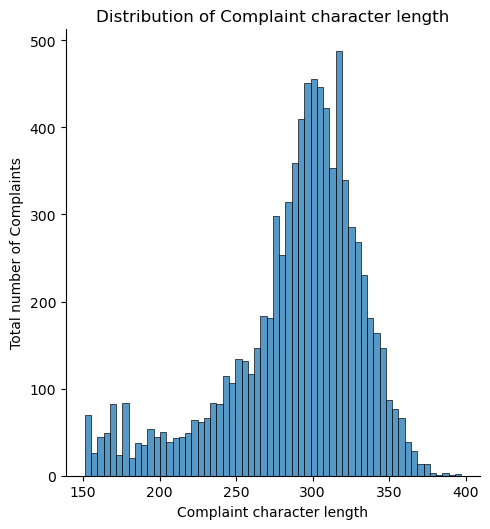

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

char_len = [len(each_sent) for each_sent in df_clean['Ticket Description']]
sns.displot(char_len, kind='hist', bins=60)
plt.xlabel("Complaint character length")
plt.ylabel("Total number of Complaints")
plt.title("Distribution of Complaint character length")
plt.show()

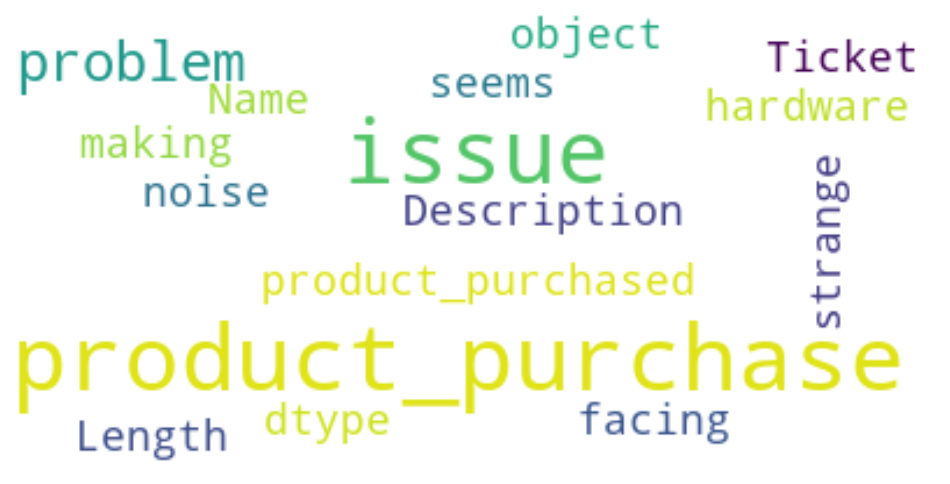

In [69]:
#Using a word cloud find the top 40 words by frequency among all the articles after processing the text
stopwords = set(STOPWORDS)
wordcloud = WordCloud(max_font_size=60, max_words=40, 
                      background_color="white", random_state=100, 
                      stopwords=stopwords).generate(str(df_clean['Ticket Description']))
plt.figure(figsize=[12,12])
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

In [75]:
#Removing -PRON- from the text corpus
df_clean['Ticket Description'] = df_clean['Ticket Description'].str.replace('-PRON-', '')

In [72]:
df.columns

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating', 'Resolution Time', 'clean_description',
       'category', 'created_at', 'resolved_at', 'response_time'],
      dtype='object')

In [73]:
print(df_clean.columns)

Index(['Ticket Description'], dtype='object')


In [80]:
df_clean = pd.DataFrame(df['Ticket Description'].apply(clean_text))

In [81]:
df_clean = pd.DataFrame(df['Ticket Description'].apply(clean_text))
df_clean.rename(columns={'Ticket Description': 'cleaned_description'}, inplace=True)

In [82]:
df_clean['complaint_lemmatized'] = df_clean['cleaned_description'].apply(lemmmatize_text)

In [83]:
df_clean['complaint_POS_removed'] = df_clean['complaint_lemmatized'].apply(get_POS_tags)

In [84]:
# Creating a function to extract top ngrams(unigram/bigram/trigram) based on the function inputs
def get_top_ngrams(text, n=None, ngram=(1,1)):
  vec = CountVectorizer(stop_words='english', ngram_range=ngram).fit(text)
  bagofwords = vec.transform(text)
  sum_words = bagofwords.sum(axis=0)
  words_frequency = [(word, sum_words[0, index]) for word, index in vec.vocabulary_.items()]
  words_frequency = sorted(words_frequency, key = lambda x: x[1], reverse=True)
  return words_frequency[:n]

In [86]:
top_30words = get_top_ngrams(df_clean['cleaned_description'].values.astype('U'), n=30, ngram=(1,1))
df_unigram = pd.DataFrame(top_30words, columns=['unigram', 'count'])
df_unigram

,unigram,count
0,product_purchased,14078
1,issue,11531
2,having,6430
3,assist,6258
4,ve,6120
5,product,2333
6,problem,2285
7,data,1664
8,software,1556
9,account,1466


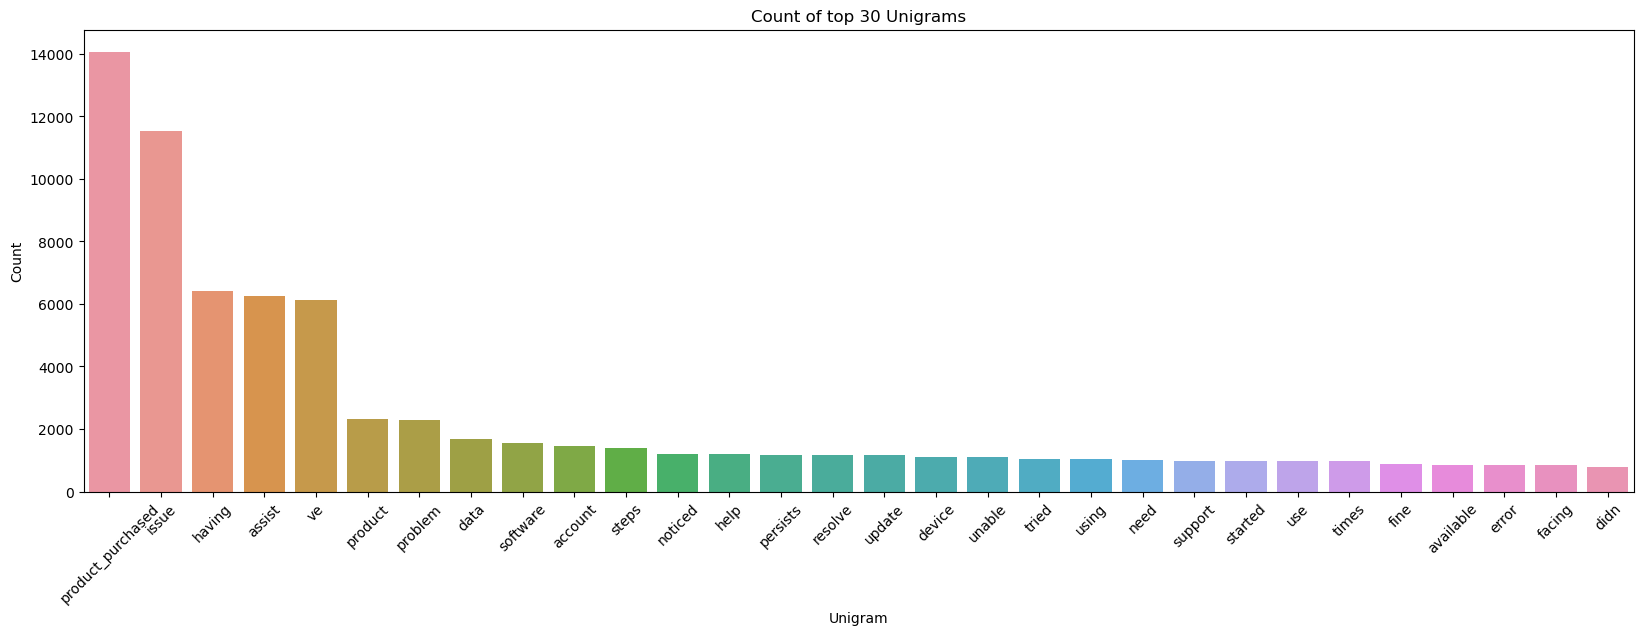

In [87]:
# Plotting top 30 Unigrams
plt.figure(figsize=[20,6])
sns.barplot(x=df_unigram['unigram'], y=df_unigram['count'])
plt.xticks(rotation=45)
plt.xlabel("Unigram")
plt.ylabel("Count")
plt.title("Count of top 30 Unigrams")
plt.show()


In [88]:
#Print the top 10 words in the unigram frequency
df_unigram.head(10)


,unigram,count
0,product_purchased,14078
1,issue,11531
2,having,6430
3,assist,6258
4,ve,6120
5,product,2333
6,problem,2285
7,data,1664
8,software,1556
9,account,1466


In [94]:
#Write your code here to find the top 30 bigram frequency among the complaints in the cleaned datafram(df_clean). 
top_30words = get_top_ngrams(df_clean['cleaned_description'].values.astype('U'), n=30, ngram=(2,2))
df_bigram = pd.DataFrame(top_30words, columns=['bigram', 'count'])
df_bigram

,bigram,count
0,issue product_purchased,6249
1,having issue,6175
2,product_purchased assist,6105
3,ve noticed,1191
4,issue persists,1176
5,product_purchased issue,994
6,ve tried,968
7,ve checked,748
8,resolve problem,747
9,troubleshooting steps,684


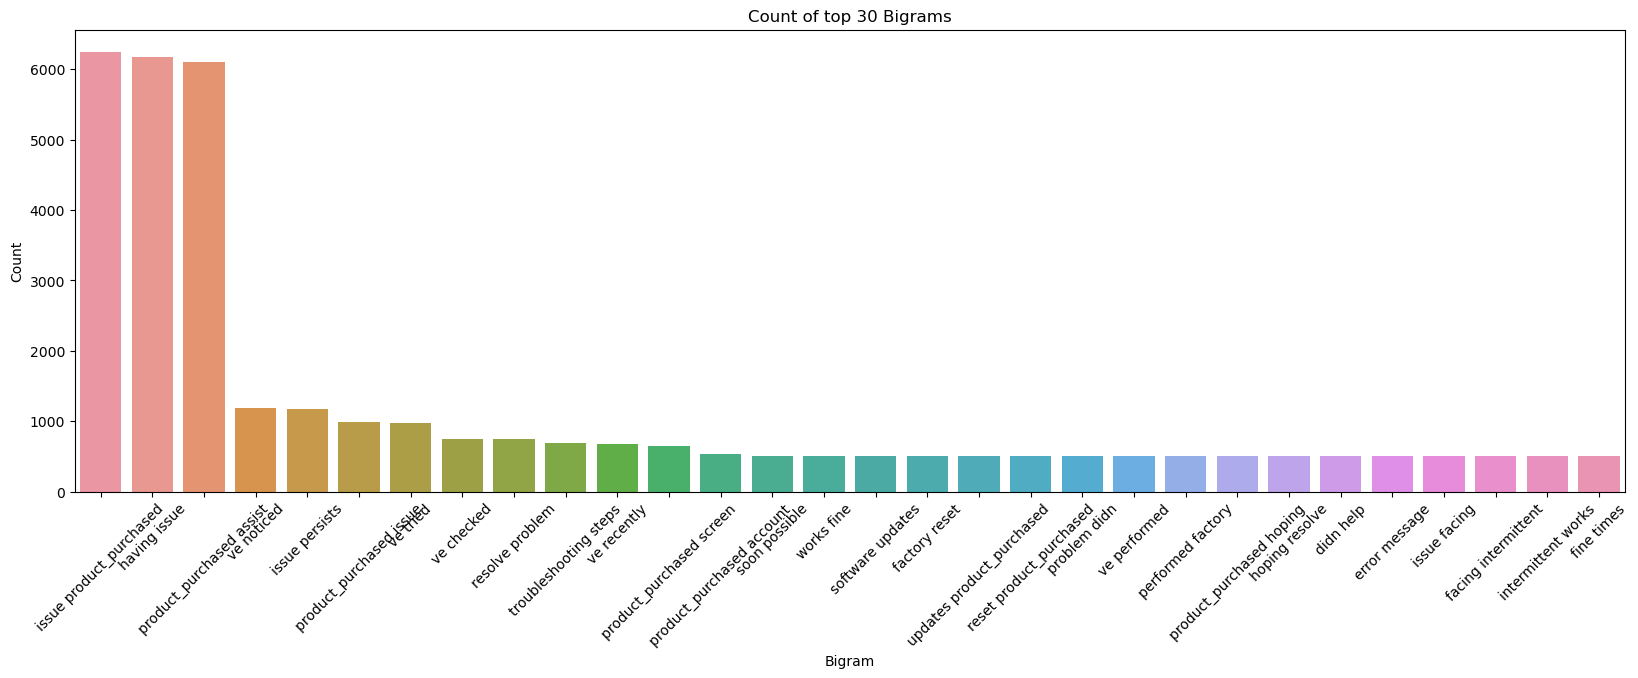

In [91]:
# Plotting top 30 Bigrams
plt.figure(figsize=[20,6])
sns.barplot(x=df_bigram['bigram'], y=df_bigram['count'])
plt.xticks(rotation=45)
plt.xlabel("Bigram")
plt.ylabel("Count")
plt.title("Count of top 30 Bigrams")
plt.show()


In [92]:
df_bigram.head(10)

,bigram,count
0,issue product_purchased,6249
1,having issue,6175
2,product_purchased assist,6105
3,ve noticed,1191
4,issue persists,1176
5,product_purchased issue,994
6,ve tried,968
7,ve checked,748
8,resolve problem,747
9,troubleshooting steps,684


In [95]:
#Write your code here to find the top 30 trigram frequency among the complaints in the cleaned datafram(df_clean). 
top_30words = get_top_ngrams(df_clean['cleaned_description'].values.astype('U'), n=30, ngram=(3,3))
df_trigram = pd.DataFrame(top_30words, columns=['trigram', 'count'])
df_trigram

,trigram,count
0,having issue product_purchased,6063
1,issue product_purchased assist,6049
2,software updates product_purchased,502
3,ve performed factory,502
4,performed factory reset,502
5,factory reset product_purchased,502
6,reset product_purchased hoping,502
7,product_purchased hoping resolve,502
8,hoping resolve problem,502
9,resolve problem didn,502


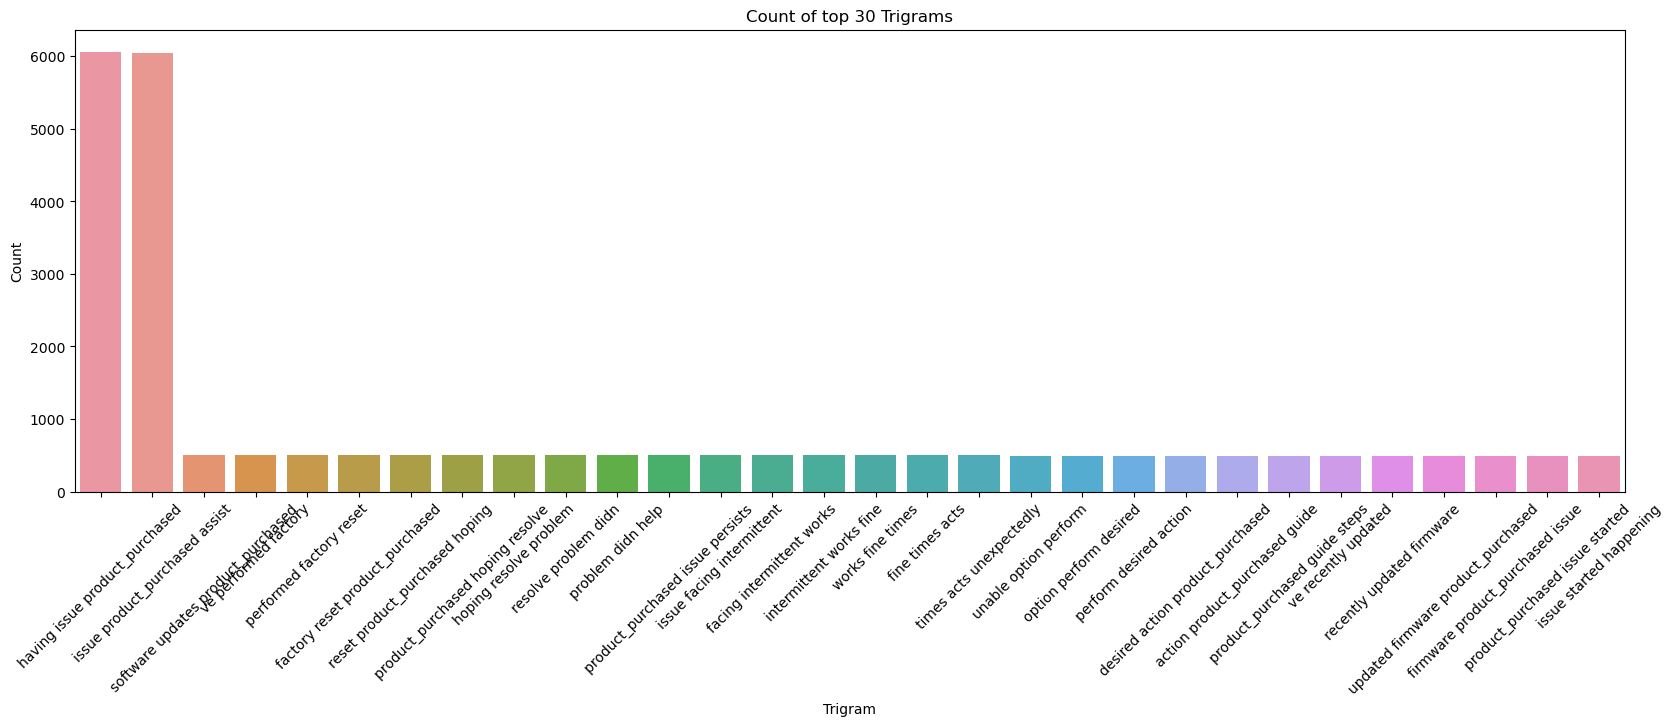

In [96]:
plt.figure(figsize=[20,6])
sns.barplot(x=df_trigram['trigram'], y=df_trigram['count'])
plt.xticks(rotation=45)
plt.xlabel("Trigram")
plt.ylabel("Count")
plt.title("Count of top 30 Trigrams")
plt.show()

In [97]:
df_trigram.head(10)

,trigram,count
0,having issue product_purchased,6063
1,issue product_purchased assist,6049
2,software updates product_purchased,502
3,ve performed factory,502
4,performed factory reset,502
5,factory reset product_purchased,502
6,reset product_purchased hoping,502
7,product_purchased hoping resolve,502
8,hoping resolve problem,502
9,resolve problem didn,502


In [100]:
df_clean['Cleaned_Description'] = df_clean['cleaned_description'].str.replace('xxxx','')

In [101]:
df_clean


,cleaned_description,complaint_lemmatized,complaint_POS_removed,Cleaned_Description
0,i'm having an issue with the {product_purchase...,I be have an issue with the { product_purchase...,issue product_purchase assist billing zip code...,i'm having an issue with the {product_purchase...
1,i'm having an issue with the {product_purchase...,I be have an issue with the { product_purchase...,issue product_purchase assist product issue pr...,i'm having an issue with the {product_purchase...
2,i'm facing a problem with my {product_purchase...,I be face a problem with my { product_purchase...,problem product_purchase product_purchase yest...,i'm facing a problem with my {product_purchase...
3,i'm having an issue with the {product_purchase...,I be have an issue with the { product_purchase...,issue product_purchase assist problem feedback...,i'm having an issue with the {product_purchase...
4,i'm having an issue with the {product_purchase...,I be have an issue with the { product_purchase...,issue product_purchase assist note seller dama...,i'm having an issue with the {product_purchase...
...,...,...,...,...
8464,my {product_purchased} is making strange noise...,my { product_purchase } be make strange noise ...,product_purchase noise issue support @ laserpr...,my {product_purchased} is making strange noise...
8465,i'm having an issue with the {product_purchase...,I be have an issue with the { product_purchase...,issue product_purchase assist sell % buy % iss...,i'm having an issue with the {product_purchase...
8466,i'm having an issue with the {product_purchase...,I be have an issue with the { product_purchase...,issue product_purchase assist browser use fact...,i'm having an issue with the {product_purchase...
8467,i'm having an issue with the {product_purchase...,I be have an issue with the { product_purchase...,issue product_purchase assist product category...,i'm having an issue with the {product_purchase...


In [102]:
#Write your code here to initialise the TfidfVectorizer 
tfidf = TfidfVectorizer(min_df=2, max_df=0.95, stop_words='english')

In [103]:
#Write your code here to create the Document Term Matrix by transforming the complaints column present in df_clean.
dtm = tfidf.fit_transform(df_clean['Cleaned_Description'])

In [104]:
dtm

<8469x2692 sparse matrix of type '<class 'numpy.float64'>'
	with 152469 stored elements in Compressed Sparse Row format>

In [105]:
from sklearn.decomposition import NMF

In [106]:
#Load your nmf_model with the n_components i.e 5
num_topics = 5

#keep the random_state =40
nmf_model = NMF(n_components=num_topics, random_state=40)

In [107]:
nmf_model.fit(dtm)
len(tfidf.get_feature_names_out())

2692

In [108]:
H = nmf_model.components_    

In [109]:
#Print the Top15 words for each of the topics
words = np.array(tfidf.get_feature_names_out())
topic_words = pd.DataFrame(np.zeros((num_topics, 15)), index=[f'Topic {i + 1}' for i in range(num_topics)],
                           columns=[f'Word {i + 1}' for i in range(15)]).astype(str)
for i in range(num_topics):
    ix = H[i].argsort()[::-1][:15]
    topic_words.iloc[i] = words[ix]

topic_words

,Word 1,Word 2,Word 3,Word 4,Word 5,Word 6,Word 7,Word 8,Word 9,Word 10,Word 11,Word 12,Word 13,Word 14,Word 15
Topic 1,issue,assist,having,persists,ve,tried,data,product,steps,user,need,troubleshooting,mentioned,manual,different
Topic 2,screen,error_message,popping,peculiar,mean,message,does,says,noticed,error,ve,assist,having,issue,product
Topic 3,update,started,software,updated,happening,firmware,afterward,recently,related,recent,occurring,haven,changes,device,issue
Topic 4,account,reset,didn,resolve,access,hoping,factory,performed,problem,help,password,unable,login,keeps,ve
Topic 5,times,fine,facing,issue,intermittent,acts,unexpectedly,works,multiple,unresolved,remains,contacted,customer,support,having


In [110]:
#Create the best topic for each complaint in terms of integer value 0,1,2,3 & 4
topic_results = nmf_model.transform(dtm)

In [112]:
df_clean['Topic'] = topic_results.argmax(axis=1)

In [113]:
df_clean.head()

,cleaned_description,complaint_lemmatized,complaint_POS_removed,Cleaned_Description,Topic
0,i'm having an issue with the {product_purchase...,I be have an issue with the { product_purchase...,issue product_purchase assist billing zip code...,i'm having an issue with the {product_purchase...,0
1,i'm having an issue with the {product_purchase...,I be have an issue with the { product_purchase...,issue product_purchase assist product issue pr...,i'm having an issue with the {product_purchase...,4
2,i'm facing a problem with my {product_purchase...,I be face a problem with my { product_purchase...,problem product_purchase product_purchase yest...,i'm facing a problem with my {product_purchase...,4
3,i'm having an issue with the {product_purchase...,I be have an issue with the { product_purchase...,issue product_purchase assist problem feedback...,i'm having an issue with the {product_purchase...,4
4,i'm having an issue with the {product_purchase...,I be have an issue with the { product_purchase...,issue product_purchase assist note seller dama...,i'm having an issue with the {product_purchase...,1


In [114]:
#Print the first 5 Complaint for each of the Topics
df_clean_5=df_clean.groupby('Topic').head(5)
df_clean_5.sort_values('Topic')

,cleaned_description,complaint_lemmatized,complaint_POS_removed,Cleaned_Description,Topic
0,i'm having an issue with the {product_purchase...,I be have an issue with the { product_purchase...,issue product_purchase assist billing zip code...,i'm having an issue with the {product_purchase...,0
16,i'm having an issue with the {product_purchase...,I be have an issue with the { product_purchase...,issue product_purchase assist acknowledgement ...,i'm having an issue with the {product_purchase...,0
13,"i've recently set up my {product_purchased}, b...",I have recently set up my { product_purchase }...,product_purchase network step issue product_ip...,"i've recently set up my {product_purchased}, b...",0
10,i'm having an issue with the {product_purchase...,I be have an issue with the { product_purchase...,issue product_purchase assist product search r...,i'm having an issue with the {product_purchase...,0
12,i'm having an issue with the {product_purchase...,I be have an issue with the { product_purchase...,issue product_purchase assist cqw invoice lot ...,i'm having an issue with the {product_purchase...,0
65,there seems to be a glitch in the {product_pur...,there seem to be a glitch in the { product_pur...,glitch software solution error message screen ...,there seems to be a glitch in the {product_pur...,1
24,i'm having an issue with the {product_purchase...,I be have an issue with the { product_purchase...,issue product_purchase assist product_purchase...,i'm having an issue with the {product_purchase...,1
15,i'm having an issue with the {product_purchase...,I be have an issue with the { product_purchase...,issue product_purchase assist please note prod...,i'm having an issue with the {product_purchase...,1
4,i'm having an issue with the {product_purchase...,I be have an issue with the { product_purchase...,issue product_purchase assist note seller dama...,i'm having an issue with the {product_purchase...,1
64,i'm facing a problem with my {product_purchase...,I be face a problem with my { product_purchase...,problem product_purchase product_purchase yest...,i'm facing a problem with my {product_purchase...,1


In [115]:
#Create the dictionary of Topic names and Topics
Topic_names = { 0:"Bank account services", 1:"Credit card / Prepaid card", 2:"Others",
               3:"Theft/Dispute reporting", 4:"Mortgages/loans" }
#Replace Topics with Topic Names
df_clean['Topic'] = df_clean['Topic'].map(Topic_names)

In [116]:
df_clean.shape

(8469, 5)

In [117]:
df_clean.head()

,cleaned_description,complaint_lemmatized,complaint_POS_removed,Cleaned_Description,Topic
0,i'm having an issue with the {product_purchase...,I be have an issue with the { product_purchase...,issue product_purchase assist billing zip code...,i'm having an issue with the {product_purchase...,Bank account services
1,i'm having an issue with the {product_purchase...,I be have an issue with the { product_purchase...,issue product_purchase assist product issue pr...,i'm having an issue with the {product_purchase...,Mortgages/loans
2,i'm facing a problem with my {product_purchase...,I be face a problem with my { product_purchase...,problem product_purchase product_purchase yest...,i'm facing a problem with my {product_purchase...,Mortgages/loans
3,i'm having an issue with the {product_purchase...,I be have an issue with the { product_purchase...,issue product_purchase assist problem feedback...,i'm having an issue with the {product_purchase...,Mortgages/loans
4,i'm having an issue with the {product_purchase...,I be have an issue with the { product_purchase...,issue product_purchase assist note seller dama...,i'm having an issue with the {product_purchase...,Credit card / Prepaid card


In [119]:
#Create the dictionary again of Topic names and Topics
Topic_names = { "Bank account services":0, "Credit card / Prepaid card":1, "Others":2,
               "Theft/Dispute reporting":3, "Mortgages/loans":4 }
#Replace Topics with Topic Names
df_clean['Topic'] = df_clean['Topic'].map(Topic_names)

In [120]:
df_clean.shape

(8469, 5)

In [125]:
#Keep the columns"complaint_what_happened" & "Topic" only in the new dataframe --> training_data
training_data = df_clean[['cleaned_description', 'Topic']]


In [126]:
training_data

,cleaned_description,Topic
0,i'm having an issue with the {product_purchase...,0
1,i'm having an issue with the {product_purchase...,4
2,i'm facing a problem with my {product_purchase...,4
3,i'm having an issue with the {product_purchase...,4
4,i'm having an issue with the {product_purchase...,1
...,...,...
8464,my {product_purchased} is making strange noise...,0
8465,i'm having an issue with the {product_purchase...,4
8466,i'm having an issue with the {product_purchase...,3
8467,i'm having an issue with the {product_purchase...,0


In [128]:
#Write your code to get the Vector count
vect = CountVectorizer()
X_train_cnt = vect.fit_transform(training_data['cleaned_description'])

# Save word vector
pickle.dump(vect.vocabulary_, open("count_vector.pk1", "wb"))

In [129]:
#Write your code here to transform the word vector to tf-idf
tfidf_transformer = TfidfTransformer()
X_train_tfidf = tfidf_transformer.fit_transform(X_train_cnt)

# Save tfidf
pickle.dump(tfidf_transformer, open('tfidf.pk1', "wb"))

In [130]:
# Importing LogisticRegression from sklearn
from sklearn.linear_model import LogisticRegression
# Importing Train, Test Split
from sklearn.model_selection import train_test_split

In [131]:
# Train, Test Split
X_train, X_test, y_train, y_test = train_test_split(X_train_tfidf, training_data['Topic'], test_size=0.25, random_state=42)

In [132]:
logreg = LogisticRegression(random_state=42, solver='liblinear').fit(X_train, y_train)

In [133]:
# Getting the score of the base model
logreg.score(X_test, y_test)

0.9546742209631728

In [134]:
logreg_grid = {"C": [100, 10, 5, 4, 3, 2, 1, 1.0, 0.1, 0.01],
                "solver": ["liblinear"]}

In [135]:
# Setup grid hyperparameter search for LogisticRegression
logreg_hpt = GridSearchCV(LogisticRegression(random_state=42),
                                param_grid=logreg_grid,
                                cv=5,
                                verbose=True,
                                n_jobs=-1)

# Fit random hyperparameter search model
logreg_hpt.fit(X_train, y_train);

Fitting 5 folds for each of 10 candidates, totalling 50 fits


In [136]:
# Check best parameters
logreg_hpt.best_params_

{'C': 100, 'solver': 'liblinear'}

In [137]:
# Evaluating the tuned model
logreg_hpt.score(X_test, y_test)

0.9660056657223796

In [140]:
# Load pickled model
logreg_model = pickle.load(open("logreg_model.pk1", "rb"))

In [141]:
# Make predictions on test data
y_pred = logreg_model.predict(X_test)

In [142]:
# Print Confusion Matrix
print(confusion_matrix(y_test, y_pred))

[[924   7   4   2   3]
 [  9 160   1   0   0]
 [ 23   0 274   1   2]
 [  7   1   2 336   3]
 [  3   0   2   2 352]]


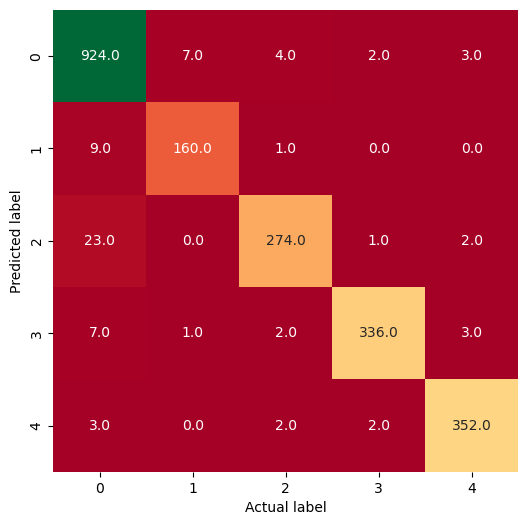

In [143]:
# Visualize Confusion Matrix with heatmap
fig, ax = plt.subplots(figsize=(6, 6))
ax = sns.heatmap(confusion_matrix(y_test, y_pred),
                 annot=True,
                 cbar=False,
                 cmap="RdYlGn", fmt = '0.1f')
plt.xlabel("Actual label")
plt.ylabel("Predicted label")
plt.show()

In [145]:
Topicnames_target = ["Bank account services", "Credit card / Prepaid card", "Others", "Theft/Dispute reporting", "Mortgages/loans"]


In [147]:
# Print Classification Report
print(classification_report(y_test, y_pred, target_names = Topicnames_target))

                            precision    recall  f1-score   support

     Bank account services       0.96      0.98      0.97       940
Credit card / Prepaid card       0.95      0.94      0.95       170
                    Others       0.97      0.91      0.94       300
   Theft/Dispute reporting       0.99      0.96      0.97       349
           Mortgages/loans       0.98      0.98      0.98       359

                  accuracy                           0.97      2118
                 macro avg       0.97      0.96      0.96      2118
              weighted avg       0.97      0.97      0.97      2118

